# 8. 직교 행렬과 QR 분해

## 직교하는 방향으로 행렬을 다시 표현하기

- **배울 것**: 직교행렬, Gram–Schmidt, QR 분해와 최소제곱 연결.
- 서로 수직이며 길이가 1인 열벡터를 모으면 $Q^TQ=I$입니다. 정사각 Q라면 $Q^{-1}=Q^T$도 성립합니다.

$$
\|Q\mathbf x\|_2^2=\mathbf x^TQ^TQ\mathbf x=\|\mathbf x\|_2^2
$$

- 직교변환은 길이와 각도를 보존합니다. 회전뿐 아니라 반사도 포함합니다.
- 직사각형의 열 직교정규 행렬은 $Q^TQ=I$여도 보통 $QQ^T\ne I$입니다.

## QR 분해의 역할 분담

$$
A=QR,\qquad Q^TQ=I,\qquad R\text{은 상삼각행렬}
$$

- Q는 중복되지 않는 직교 방향을, R은 원래 열을 그 방향으로 조합하는 가중치를 담습니다.
- 예를 들어 $A=\begin{bmatrix}1&1\\1&0\end{bmatrix}$의 첫 q는 $(1,1)/\sqrt2$입니다. 두 번째 열에서 이 방향 성분을 빼면 $(1/2,-1/2)$가 남습니다.
- 이를 정규화하면 두 번째 q는 $(1,-1)/\sqrt2$입니다. 구현에 따라 두 열의 부호가 바뀌어도 대응하는 R의 부호가 함께 바뀌면 같은 A를 만듭니다.

$$
\mathbf u_i=\mathbf a_i-\sum_{j<i}(\mathbf q_j^T\mathbf a_i)\mathbf q_j,
\qquad \mathbf q_i=\frac{\mathbf u_i}{\|\mathbf u_i\|}
$$

- Gram–Schmidt는 이미 얻은 방향을 빼고 남은 것을 정규화합니다. 선형종속 열에서는 남은 길이가 0이므로 처리가 필요합니다.
- 원본의 고전적 Gram–Schmidt는 원리를 보여 주는 구현입니다. 매우 가까운 방향에서는 직교성이 손상될 수 있습니다.
- `np.linalg.qr(A)`의 기본 reduced 모드에서 $k=\min(m,n)$, Q의 크기는 $m\times k$, R은 $k\times n$입니다.

## 왜 최소제곱에 유용할까?

$$
R\hat\beta=Q^Ty
$$

- 완전열랭크 설계행렬이면 상삼각 시스템을 풀어 회귀계수를 구할 수 있습니다. $X^TX$를 만들며 조건수를 제곱하는 문제를 피합니다.
- 정사각 완전랭크 A는 $A^{-1}=R^{-1}Q^T$입니다. 실무에서는 R의 역행렬을 만들기보다 삼각 시스템을 풉니다.
- **주의**: 직교행렬의 스펙트럴 노름은 1, $n\times n$ 직교행렬의 프로베니우스 노름은 $\sqrt n$입니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch08'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260933)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260933)

재현용 난수 시드: 20260933


### 코드 08-01

- 원본: `original_py/LA4DS_ch08.py` 1–11행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# used to create non-regular subplots
import matplotlib.gridspec as gridspec


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 직교행렬

### 코드 08-02

- 원본: `original_py/LA4DS_ch08.py` 15–22행.

In [3]:
# specify the matrices
Q1 = np.array([ [1,-1],[1,1] ]) / np.sqrt(2)
Q2 = np.array([ [1,2,2],[2,1,-2],[-2,2,-1] ]) / 3

# should be I (to within rounding error...)
print( np.round(Q1.T @ Q1,8) ), print(' ')

print( np.round(Q2.T @ Q2,8) )

[[1. 0.]
 [0. 1.]]
 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### QR 분해

### 코드 08-03

- 원본: `original_py/LA4DS_ch08.py` 26–67행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

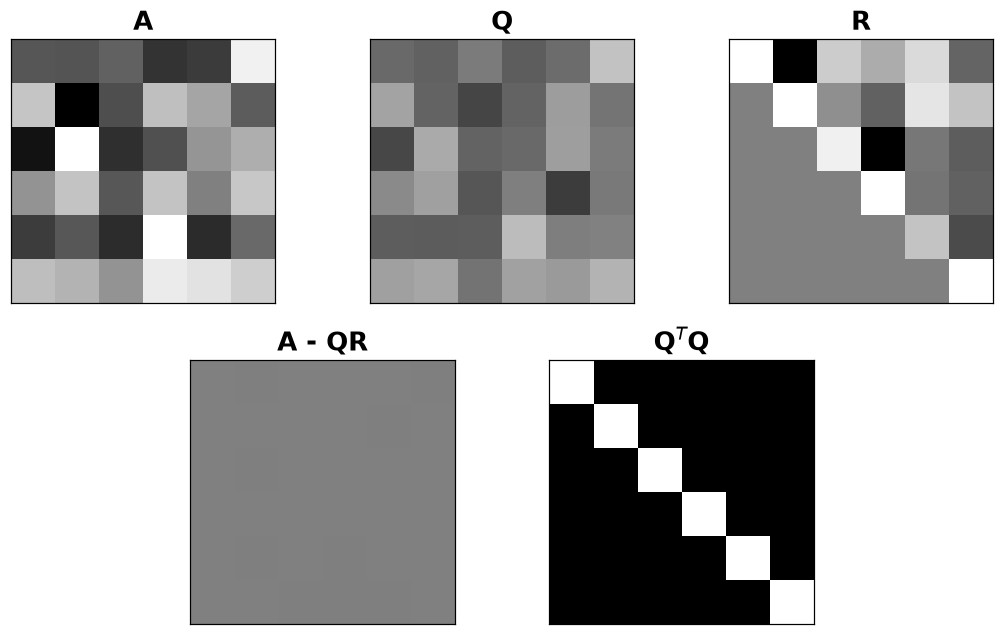

In [4]:
# create a random matrix
A = np.random.randn(6,6)

# QR decomposition
Q,R = np.linalg.qr(A)



# show the matrices
fig = plt.figure(figsize=(10,6))
axs = [0]*5
c = 1.5 # color limits

gs1 = gridspec.GridSpec(2,6)
axs[0] = plt.subplot(gs1[0,:2])
axs[0].imshow(A,vmin=-c,vmax=c,cmap='gray')
axs[0].set_title('A',fontweight='bold')

axs[1] = plt.subplot(gs1[0,2:4])
axs[1].imshow(Q,vmin=-c,vmax=c,cmap='gray')
axs[1].set_title('Q',fontweight='bold')

axs[2] = plt.subplot(gs1[0,4:6])
axs[2].imshow(R,vmin=-c,vmax=c,cmap='gray')
axs[2].set_title('R',fontweight='bold')

axs[3] = plt.subplot(gs1[1,1:3])
axs[3].imshow(A - Q@R,vmin=-c,vmax=c,cmap='gray')
axs[3].set_title('A - QR',fontweight='bold')

axs[4] = plt.subplot(gs1[1,3:5])
axs[4].imshow(Q.T@Q,cmap='gray')
axs[4].set_title(r'Q$^T$Q',fontweight='bold')

# remove ticks from all axes
for a in axs:
  a.set_xticks([])
  a.set_yticks([])

plt.tight_layout()
plt.savefig(ASSET / 'Figure_08_01.png',dpi=140)
plt.show()

### 코드 08-04

- 원본: `original_py/LA4DS_ch08.py` 71–82행.

In [5]:
# QR and matrix sizes

M = 4
N = 14

A = np.random.randn(M,N)
Q,R = np.linalg.qr(A)

# print the results
print(f'Size of A (M,N): {A.shape}')
print(f'Size of Q (M,N): {Q.shape}')
print(f'Size of R (M,N): {R.shape}')

Size of A (M,N): (4, 14)
Size of Q (M,N): (4, 4)
Size of R (M,N): (4, 14)


### 코드 08-05

- 원본: `original_py/LA4DS_ch08.py` 84–89행.

In [6]:
# illustration of full Q from M>N A

A = np.array([ [1,-1] ]).T

Q,R = np.linalg.qr(A,'complete')
Q*np.sqrt(2)

Out[6]: 
array([[-1.,  1.],
       [ 1.,  1.]])


## 연습문제 1 · 전치와 역행렬 비교

- **목표**: 정사각 직교행렬의 역행렬이 전치임을 확인합니다.
- **풀이 순서**: QR로 Q를 만든 후 QtQ, QQt, inv(Q)Q, Qinv(Q)를 계산합니다.
- **결과 해석**: 네 결과는 모두 항등행렬입니다. 직사각형 Q에 양쪽 성질을 그대로 적용하지 않습니다.

### 코드 08-06

- 원본: `original_py/LA4DS_ch08.py` 95–110행.

In [7]:
# compute matrices
Q  = np.linalg.qr( np.random.randn(5,5) )[0]
Qt = Q.T
Qi = np.linalg.inv( Q )

# QtQ
print(np.round( Qt@Q,8 )), print(' ')

# QQt
print(np.round( Q@Qt,8 )), print(' ')

# Q^-1 Q
print(np.round( Qi@Q,8 )), print(' ')

# QQ^-1
print(np.round( Q@Qi,8 ))

[[ 1. -0. -0. -0.  0.]
 [-0.  1.  0. -0.  0.]
 [-0.  0.  1. -0. -0.]
 [-0. -0. -0.  1. -0.]
 [ 0.  0. -0. -0.  1.]]
 
[[ 1. -0.  0.  0.  0.]
 [-0.  1. -0.  0. -0.]
 [ 0. -0.  1. -0. -0.]
 [ 0.  0. -0.  1.  0.]
 [ 0. -0. -0.  0.  1.]]
 
[[ 1. -0. -0. -0. -0.]
 [-0.  1.  0.  0. -0.]
 [-0. -0.  1. -0. -0.]
 [ 0.  0.  0.  1.  0.]
 [-0.  0.  0. -0.  1.]]
 
[[ 1.  0.  0.  0. -0.]
 [-0.  1. -0. -0.  0.]
 [ 0. -0.  1.  0.  0.]
 [-0.  0.  0.  1.  0.]
 [ 0.  0. -0.  0.  1.]]


## 연습문제 2 · Gram–Schmidt 구현

- **목표**: 앞에서 얻은 방향을 제거하며 직교기저를 만듭니다.
- **풀이 순서**: 각 열에서 이전 q방향 투영을 빼고 정규화합니다. NumPy QR의 Q와 합·차를 비교합니다.
- **결과 해석**: 열마다 부호가 다를 수 있습니다. 차이만으로 틀렸다고 하지 말고 Q의 직교성과 QR 재구성을 확인합니다.

### 코드 08-07

- 원본: `original_py/LA4DS_ch08.py` 115–147행.

In [8]:
# create the matrix 
m = 4
n = 4
A = np.random.randn(m,n)

# initialize
Q = np.zeros((m,n))


# the GS algo
for i in range(n):
    
    # initialize
    Q[:,i] = A[:,i]
    
    # orthogonalize
    a = A[:,i] # convenience
    for j in range(i): # only to earlier cols
        q = Q[:,j] # convenience
        Q[:,i]=Q[:,i]-np.dot(a,q)/np.dot(q,q)*q
    
    # normalize
    Q[:,i] = Q[:,i] / np.linalg.norm(Q[:,i])

    
# "real" QR decomposition for comparison
Q2,R = np.linalg.qr(A)


# note the possible sign differences.
# seemingly non-zero columns will be 0 when adding
print( np.round( Q-Q2 ,10) ), print(' ')
print( np.round( Q+Q2 ,10) )

[[ 0.822764  0.93577  -0.095508 -1.561497]
 [-0.011649  1.715883  0.183335  1.010939]
 [ 1.752937 -0.424165  0.588233  0.633464]
 [-0.500134  0.012787  1.900328 -0.372094]]
 
[[-0. -0. -0. -0.]
 [ 0.  0.  0. -0.]
 [ 0. -0. -0. -0.]
 [ 0.  0.  0. -0.]]


## 연습문제 3 · 직교 열을 변경한 뒤 QR

- **목표**: 열 길이 변화와 방향 변화가 R에 어떻게 나타나는지 봅니다.
- **풀이 순서**: 직교행렬의 각 열에 다른 배율을 곱하고 원소 하나를 0으로 바꾼 뒤 QR을 계산합니다.
- **결과 해석**: 길이만 바꾸면 R은 대각 형태지만 원소 하나 수정은 다른 열 방향 성분을 만들어 비대각 성분을 발생시킵니다. 단계를 주석 처리해 비교할 수 있습니다.

### 코드 08-08

- 원본: `original_py/LA4DS_ch08.py` 151–169행.

In [9]:
# create an orthogonal matrix, call it U (to avoid confusing with Q)
U = np.linalg.qr( np.random.randn(6,6) )[0]


# part 2: modulate the column norms
for i in range(U.shape[0]):
  U[:,i] = U[:,i]*(10+i)


# part 3: Change one matrix element
U[0,3] = 0 # this is q_{1,4}


# QR decomp
q,r = np.linalg.qr(U)

# show R and, for part 2, Q'Q
print( np.round(r,3) ), print(' ')
# print( np.round(Q.T@Q,4))

[[10.    -0.     0.     1.2    0.     0.   ]
 [ 0.    11.    -0.    -4.614 -0.    -0.   ]
 [ 0.     0.    12.     1.63  -0.     0.   ]
 [ 0.     0.     0.    10.549 -0.699  0.989]
 [ 0.     0.     0.     0.    13.983  0.049]
 [ 0.     0.     0.     0.     0.    14.967]]
 
Out[9]: (None, None)


## 연습문제 4 · 여인수 역행렬과 QR 결합

- **목표**: 동일한 역행렬 공식을 다른 행렬에 적용해 오차를 비교합니다.
- **풀이 순서**: 직접 만든 여인수 함수로 inv(A)를 계산하고, QR 후 inv(R)Qt 방식도 계산합니다. 두 재구성 오차를 그립니다.
- **결과 해석**: 한 번의 난수 실험에서 더 작은 오차가 나온 방법이 항상 우수하다는 결론은 피합니다. 두 방법 모두 작은 행렬의 교육용 비교입니다.

### 코드 08-09

- 원본: `original_py/LA4DS_ch08.py` 173–215행.

In [10]:
# a function to compute the inverse
def oldSchoolInv(A):

  # matrix size
  m = A.shape[0]


  # abort if non-square
  if not np.diff(A.shape)[0]==0:
    raise Exception('Matrix must be square.')
  
  # abort if singular
  if np.linalg.matrix_rank(A)<m:
    raise Exception('Matrix must be full-rank.')


  # initialize
  M = np.zeros((m,m)) # minors matrix
  G = np.zeros((m,m)) # grid matrix

  # compute minors matrix
  for i in range(m):
    for j in range(m):
      
      # select rows and cols
      rows = [True]*m
      rows[i] = False
      
      cols = [True]*m
      cols[j] = False
      
      # compute the minors
      M[i,j]=np.linalg.det(A[rows,:][:,cols])
      
      # compute Grid
      G[i,j] = (-1)**(i+j)

          
  # compute cofactors matrix
  C = M * G

  # compute adjugate matrix
  return C.T / np.linalg.det(A)

### 코드 08-10

- 원본: `original_py/LA4DS_ch08.py` 217–248행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

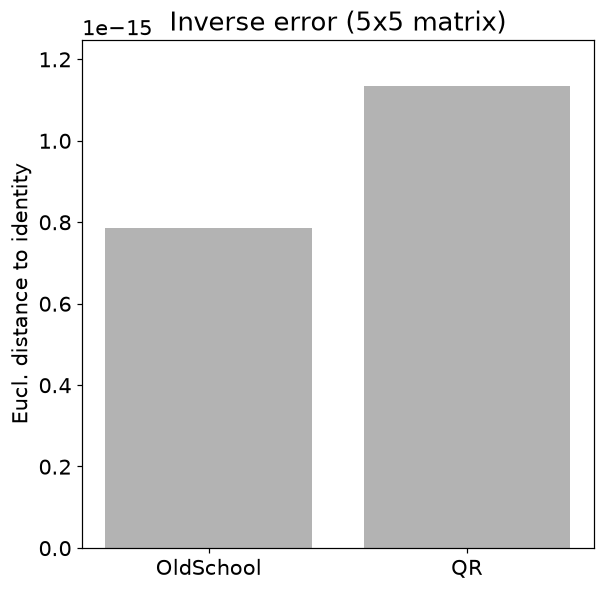

In [11]:
# create a matrix
n = 5
A = np.random.randn(n,n)

# old-school inverse method
Ainv_old = oldSchoolInv(A)
AAi_old  = Ainv_old@A

# via QR
Q,R = np.linalg.qr(A)
Ainv_qr = oldSchoolInv(R)@Q.T
AAi_qr  = Ainv_qr@A



# differences
trueI = np.eye(n)
sse = [0,0] # sse = sum of squared errors
sse[0] = np.sqrt(np.sum((AAi_old-trueI)**2))
sse[1] = np.sqrt(np.sum((AAi_qr-trueI )**2))


# and plot
plt.figure(figsize=(6,6))

plt.bar(range(2),sse,color=[.7,.7,.7])
plt.xticks(range(2),labels=['OldSchool','QR'])
plt.ylim([0,np.max(sse)*1.1])
plt.ylabel('Eucl. distance to identity')
plt.title(f'Inverse error ({n}x{n} matrix)',ha='center')
plt.savefig(ASSET / 'Figure_08_03.png',dpi=140)
plt.show()

## 연습문제 5 · 반복 실험으로 오차 분포 보기

- **목표**: 우연한 한 표본의 결과와 여러 표본의 경향을 구분합니다.
- **풀이 순서**: 100개 행렬에서 앞의 두 역행렬 방식을 반복하고 각 오차와 평균을 표시합니다.
- **결과 해석**: 일부 조건 나쁜 행렬이 평균을 크게 올릴 수 있습니다. 수치 알고리즘 비교에는 분포와 조건수도 중요합니다.

### 코드 08-11

- 원본: `original_py/LA4DS_ch08.py` 252–294행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

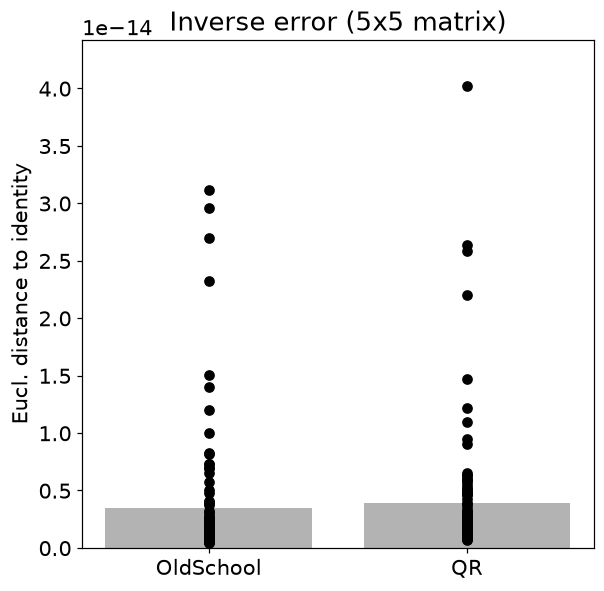

In [12]:
# run experiment

# matrix size
n = 5

numExprs = 100

sse = np.zeros((numExprs,2))

for expi in range(numExprs):

  # create matrix
  A = np.random.randn(n,n)

  # old-school inverse method
  Ainv_old = oldSchoolInv(A)
  AAi_old  = Ainv_old@A

  # via QR
  Q,R = np.linalg.qr(A)
  Ainv_qr = oldSchoolInv(R)@Q.T # using the old-school method
  # Ainv_qr = np.linalg.inv(R)@Q.T # using numpy's inv
  AAi_qr  = Ainv_qr@A

  # differences
  trueI = np.eye(n)
  sse[expi,0] = np.sqrt(np.sum((AAi_old-trueI)**2))
  sse[expi,1] = np.sqrt(np.sum((AAi_qr-trueI )**2))


# and plot
plt.figure(figsize=(6,6))

plt.plot(np.zeros(numExprs),sse[:,0],'ko')
plt.plot(np.ones(numExprs),sse[:,1],'ko')
plt.bar(range(2),np.mean(sse,axis=0),color=[.7,.7,.7])

plt.xticks(range(2),labels=['OldSchool','QR'])
plt.ylim([0,np.max(sse)*1.1])
plt.ylabel('Eucl. distance to identity')
plt.title(f'Inverse error ({n}x{n} matrix)',ha='center')
plt.savefig(ASSET / 'Figure_08_04a.png',dpi=140)
plt.show()

### 코드 08-12

- 원본: `original_py/LA4DS_ch08.py` 296–308행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

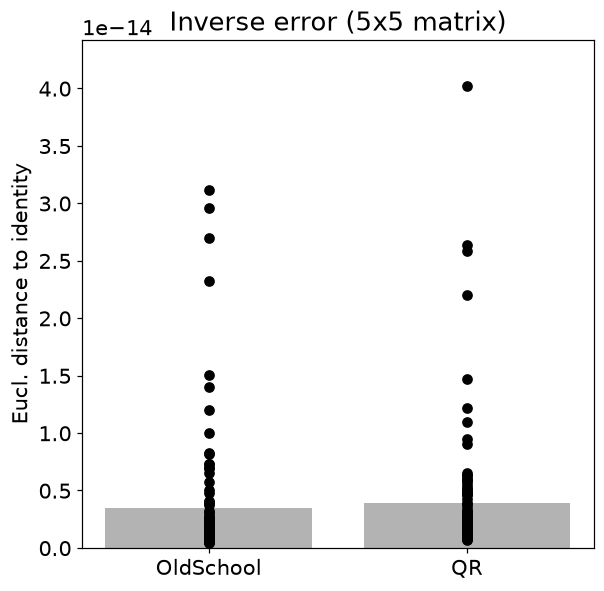

In [13]:
# and plot
plt.figure(figsize=(6,6))

plt.plot(np.zeros(numExprs),sse[:,0],'ko')
plt.plot(np.ones(numExprs),sse[:,1],'ko')
plt.bar(range(2),np.mean(sse,axis=0),color=[.7,.7,.7])

plt.xticks(range(2),labels=['OldSchool','QR'])
plt.ylim([0,np.max(sse)*1.1])
plt.ylabel('Eucl. distance to identity')
plt.title(f'Inverse error ({n}x{n} matrix)',ha='center')
plt.savefig(ASSET / 'Figure_08_04b.png',dpi=140)
plt.show()

## 연습문제 6 · 직교행렬의 노름

- **목표**: 행렬 노름 두 종류와 벡터 길이 보존을 구분합니다.
- **풀이 순서**: 13×13 Q의 2-노름, 프로베니우스 노름/√13을 구하고 임의 벡터의 변환 전후 길이를 비교합니다.
- **결과 해석**: 앞의 두 값은 1, 벡터 길이 두 값도 같습니다. Frobenius 노름 자체가 1이라는 뜻은 아닙니다.

### 코드 08-13

- 원본: `original_py/LA4DS_ch08.py` 312–319행.

In [14]:
# create a random orthogonal matrix
n = 13
Q,R = np.linalg.qr(np.random.randn(n,n))

# print out the norms
print( np.linalg.norm(Q,2),               # induced 2-norm
       np.sqrt( np.sum(Q**2) )/np.sqrt(n) # manually computed Frobenius norm
)

1.0000000000000004 1.0


### 코드 08-14

- 원본: `original_py/LA4DS_ch08.py` 321–332행.

In [15]:
# effects of matrix multiplication on vector norm

# a random vector
v = np.random.randn(n,1)

# norms
norm_v  = np.linalg.norm(v)
norm_Qv = np.linalg.norm(Q@v)

# print them
print(norm_v)
print(norm_Qv)

3.1203581252144157
3.1203581252144157


## 연습문제 7 · 키 큰 R의 왼쪽 역행렬

- **목표**: complete QR에서 생기는 0행과 가역 블록을 이해합니다.
- **풀이 순서**: 10×4 A를 complete QR로 분해하면 R은 10×4입니다. 위쪽 4×4 역행렬과 R의 pinv를 비교합니다.
- **결과 해석**: pinv는 4×10이며 위쪽 가역 블록의 역행렬 오른쪽에 0열들이 붙는 구조입니다. 전체 R에는 보통 역행렬이 없습니다.

### 코드 08-15

- 원본: `original_py/LA4DS_ch08.py` 336–343행.

In [16]:
# the matrix
A = np.random.randn(10,4)

# get R
_,R = np.linalg.qr(A,'complete')

# examine R
np.round(R,3)

Out[16]: 
array([[-2.947,  1.094, -0.957, -0.41 ],
       [ 0.   ,  2.678, -0.89 , -0.349],
       [ 0.   ,  0.   , -3.322, -1.605],
       [ 0.   ,  0.   ,  0.   ,  2.441],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ]])


### 코드 08-16

- 원본: `original_py/LA4DS_ch08.py` 345–357행.

In [17]:
# invertible submatrix
Rsub = R[:4,:]

# inverses
Rsub_inv = np.linalg.inv(Rsub)
Rleftinv = np.linalg.pinv(R)

# print out both
print('Full inverse of R submatrix:')
print(np.round(Rsub_inv,3)), print(f'\n\n')

print('Left inverse of R:')
print(np.round(Rleftinv,3))

Full inverse of R submatrix:
[[-0.339  0.139  0.061  0.003]
 [ 0.     0.373 -0.1   -0.012]
 [-0.    -0.    -0.301 -0.198]
 [ 0.     0.     0.     0.41 ]]



Left inverse of R:
[[-0.339  0.139  0.061  0.003  0.     0.     0.     0.     0.     0.   ]
 [-0.     0.373 -0.1   -0.012  0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.    -0.301 -0.198  0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.41   0.     0.     0.     0.     0.     0.   ]]


## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [18]:
_A=np.array([[1.,1.],[1.,0.],[0.,1.]])
_Q,_R=np.linalg.qr(_A)
print('Q shape:',_Q.shape,'R shape:',_R.shape)
print('직교 오차:',np.linalg.norm(_Q.T@_Q-np.eye(2)))
print('재구성 오차:',np.linalg.norm(_A-_Q@_R))
assert np.allclose(_Q.T@_Q,np.eye(2)) and np.allclose(_A,_Q@_R)


Q shape: (3, 2) R shape: (2, 2)
직교 오차: 5.173404042009138e-16
재구성 오차: 6.716134489646879e-16
